REGIME DETECTION - AUTOCORRELATION METHOD

Loading data...
✓ Loaded 1238 rows

Calculating autocorrelation...
✓ Autocorrelation calculated

Detecting regimes...

Regime distribution:
  Trending: 481 days (39.5%)
  Mean Reversion: 738 days (60.5%)

Number of regime switches: 149
Average days per regime: 8.2

Autocorrelation by regime:
  Trending regime - Avg autocorr: 0.1279
  Mean-Reversion regime - Avg autocorr: -0.1938

✓ Saved to data/spy_with_autocorr_regimes.csv

Creating visualization...
✓ Chart saved to output/regime_detection_autocorr.png


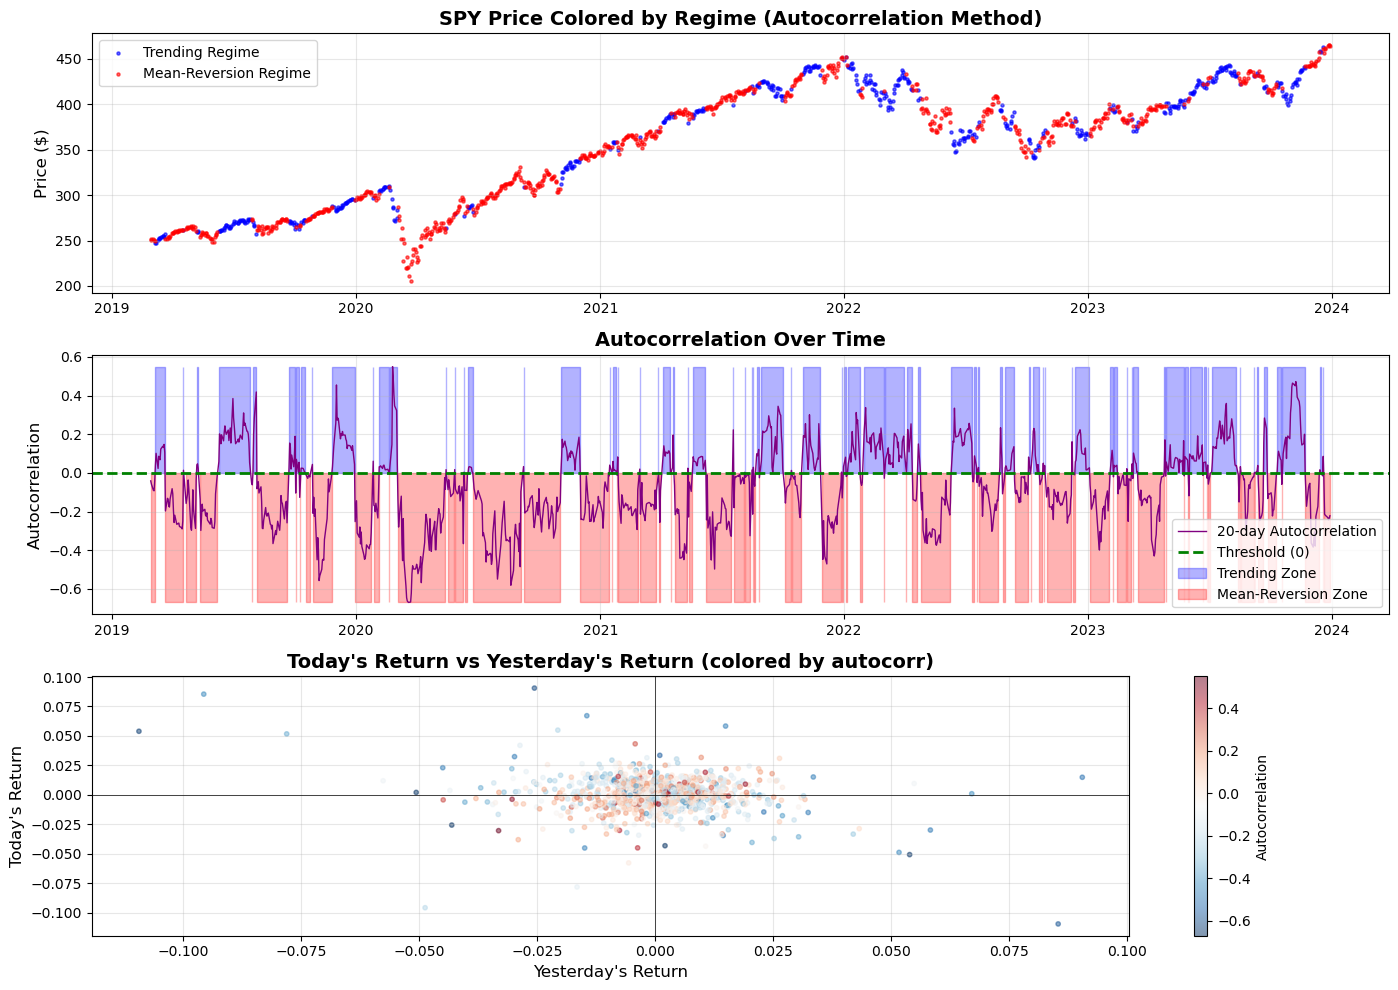


REGIME DETECTION COMPLETE!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("REGIME DETECTION - AUTOCORRELATION METHOD")
print("="*50)

# Load processed data
print("\nLoading data...")
data = pd.read_csv('data/spy_processed.csv', index_col='Date', parse_dates=True)
print(f"✓ Loaded {len(data)} rows")

# Calculate rolling autocorrelation (20-day window)
print("\nCalculating autocorrelation...")
def calculate_rolling_autocorr(series, window=20):
    """Calculate rolling autocorrelation with lag=1"""
    return series.rolling(window).apply(lambda x: x.autocorr(lag=1), raw=False)

data['autocorr'] = calculate_rolling_autocorr(data['returns'], window=20)
print(" Autocorrelation calculated")

data = data.dropna()

# Detect regimes based on autocorrelation
print("\nDetecting regimes...")
threshold = 0  # Zero is natural threshold

# Positive autocorr = trending, Negative = mean reverting
data['regime_autocorr'] = np.where(data['autocorr'] > threshold, 'Trending', 'Mean_Reversion')

# Count regimes
regime_counts = data['regime_autocorr'].value_counts()
print(f"\nRegime distribution:")
print(f"  Trending: {regime_counts.get('Trending', 0)} days ({regime_counts.get('Trending', 0)/len(data)*100:.1f}%)")
print(f"  Mean Reversion: {regime_counts.get('Mean_Reversion', 0)} days ({regime_counts.get('Mean_Reversion', 0)/len(data)*100:.1f}%)")

# Count regime switches
switches = (data['regime_autocorr'] != data['regime_autocorr'].shift()).sum()
print(f"\nNumber of regime switches: {switches}")
print(f"Average days per regime: {len(data) / switches:.1f}")

# Stats by regime
print("\nAutocorrelation by regime:")
trending = data[data['regime_autocorr'] == 'Trending']['autocorr']
meanrev = data[data['regime_autocorr'] == 'Mean_Reversion']['autocorr']
print(f"  Trending regime - Avg autocorr: {trending.mean():.4f}")
print(f"  Mean-Reversion regime - Avg autocorr: {meanrev.mean():.4f}")

# Save data
data.to_csv('data/spy_with_autocorr_regimes.csv')
print(f"\n✓ Saved to data/spy_with_autocorr_regimes.csv")

# Visualize
print("\nCreating visualization...")
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Chart 1
trending_mask = data['regime_autocorr'] == 'Trending'
meanrev_mask = data['regime_autocorr'] == 'Mean_Reversion'

axes[0].scatter(data[trending_mask].index, data[trending_mask]['Close'], 
                c='blue', s=5, alpha=0.6, label='Trending Regime')
axes[0].scatter(data[meanrev_mask].index, data[meanrev_mask]['Close'], 
                c='red', s=5, alpha=0.6, label='Mean-Reversion Regime')
axes[0].set_title('SPY Price Colored by Regime (Autocorrelation Method)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/regime_detection_autocorr.png', dpi=300, bbox_inches='tight')
print(f"✓ Chart saved to output/regime_detection_autocorr.png")

plt.show()

print("\n" + "="*50)
print("REGIME DETECTION COMPLETE!")
print("="*50)